
# 15. Resampling, Regularization, Validation, and Model Selection

By the time analysts reach the modeling stage, it is tempting to frame the whole problem as a contest: fit several algorithms, find the smallest error, and declare a winner. That habit is dangerous. If we keep checking performance on the same data until one model looks best, we can easily mistake noise for structure. Flexible models can appear brilliant in-sample and disappoint the moment the environment shifts. Even honest validation can become subtly dishonest if the same split is reused too many times.

Here we focus on how to resist that trap. We will use one operational forecasting problem and walk through the logic of train-validation-test splitting, resampling-based performance estimation, regularization, and final model selection. The central theme is simple: **a useful model is not the one that fits the observed sample most aggressively; it is the one most likely to generalize well enough to support action.**

The concrete example is a staffing-forecast problem. A support organization wants to predict next week's overflow labor hours so it can decide whether to bring in temporary analysts, rebalance queues, or tighten escalation rules. Underestimating overflow leaves the system understaffed and raises service risk. Overestimating it wastes budget. That makes generalization error a decision variable with practical consequences.



## Learning Objectives

After working through this lecture, you should be able to:

- explain why train, validation, and test data play different roles in honest predictive modeling;
- recognize overfitting by comparing apparent training performance against held-out performance;
- understand regularization as a bias-variance tradeoff tool with practical modeling consequences;
- tune ridge and lasso models using validation data while distinguishing tuning from final evaluation;
- use repeated cross-validation and bootstrap optimism as complementary checks on model stability;
- compare candidate models by raw predictive accuracy, dispersion, interpretability, and decision usefulness;
- articulate a model recommendation in language that acknowledges uncertainty without collapsing into indecision.


## Mathematical Core: Validation, Regularization, and Model Selection

A predictive model is usually chosen by estimating future error, not by minimizing training error. For a loss function `L`, empirical training risk is

$$
\widehat{R}_{\text{train}}(f)
= \frac{1}{n_{\text{train}}}\sum_{i \in \text{train}} L\left(y_i, f(x_i)\right).
$$

Validation estimates performance on data not used to fit the model:

$$
\widehat{R}_{\text{val}}(f)
= \frac{1}{n_{\text{val}}}\sum_{i \in \text{val}} L\left(y_i, f(x_i)\right).
$$

K-fold cross-validation averages validation loss across folds:

$$
\widehat{R}_{\text{CV}}(f)
= \frac{1}{K}\sum_{k=1}^{K}
\frac{1}{|V_k|}\sum_{i \in V_k} L\left(y_i, \widehat{f}_{-k}(x_i)\right).
$$

Regularization changes the optimization problem by penalizing complexity. Ridge regression solves

$$
\min_{\beta}
\sum_{i=1}^{n} \left(y_i - x_i^{T}\beta\right)^2
+ \lambda \sum_{j=1}^{p} \beta_j^2,
$$

while lasso solves

$$
\min_{\beta}
\sum_{i=1}^{n} \left(y_i - x_i^{T}\beta\right)^2
+ \lambda \sum_{j=1}^{p} |\beta_j|.
$$

The tuning parameter $\lambda$ controls the bias-variance tradeoff. Small penalties can overfit; large penalties can underfit. The decision-science question is which model has stable enough performance to support the intended action.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
np.random.seed(15)


def make_staffing_forecast_data(n=2600, seed=15):
    """
    Construct the staffing forecast data object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame of weekly staffing-forecast rows with workload drivers, noise variables, and next-week overflow hours.
    
    Idea:
        Construct a staffing-demand dataset with trend, seasonality, and workload drivers so validation reflects realistic forecasting pressure.
    """
    rng = np.random.default_rng(seed)

    demand_index = rng.normal(0, 1, n)
    workforce_index = rng.normal(0, 1, n)
    process_fragility = rng.normal(0, 1, n)

    incoming_cases = np.clip(220 + 48 * demand_index + 10 * process_fragility + rng.normal(0, 16, n), 90, 420)
    backlog_hours = np.clip(60 + 16 * demand_index - 11 * workforce_index + 12 * process_fragility + rng.normal(0, 9, n), 8, 180)
    complex_case_share = np.clip(0.25 + 0.06 * demand_index + 0.08 * process_fragility + rng.normal(0, 0.05, n), 0.05, 0.75)
    automation_rate = np.clip(0.56 - 0.05 * process_fragility + 0.05 * workforce_index + rng.normal(0, 0.05, n), 0.05, 0.95)
    analyst_capacity = np.clip(165 + 24 * workforce_index - 6 * demand_index + rng.normal(0, 11, n), 90, 245)
    queue_variability = np.clip(0.18 + 0.08 * np.abs(demand_index) + 0.08 * process_fragility + rng.normal(0, 0.03, n), 0.04, 0.70)
    holiday_week = rng.binomial(1, 1 / (1 + np.exp(-(-1.4 + 0.45 * demand_index))))
    enterprise_share = np.clip(0.34 + 0.05 * process_fragility + rng.normal(0, 0.04, n), 0.08, 0.80)
    prior_escalations = np.clip(rng.poisson(lam=np.exp(1.05 + 0.22 * process_fragility + 0.12 * demand_index)), 0, 25)

    case_pressure = incoming_cases / analyst_capacity
    noise_1 = rng.normal(0, 1, n)
    noise_2 = rng.normal(0, 1, n)
    noise_3 = rng.uniform(-1, 1, n)

    signal = (
        16
        + 0.11 * (incoming_cases - 220)
        + 0.43 * backlog_hours
        + 72 * complex_case_share
        - 0.18 * analyst_capacity
        - 26 * automation_rate
        + 18 * queue_variability
        + 8 * holiday_week
        + 12 * enterprise_share
        + 0.95 * prior_escalations
        + 34 * np.maximum(case_pressure - 1.05, 0) ** 2
        + 42 * complex_case_share * queue_variability
        - 12 * automation_rate * enterprise_share
    )

    noise_sd = 7 + 5 * queue_variability + 5 * complex_case_share + 2 * holiday_week
    overflow_hours_next_week = np.clip(signal + rng.normal(0, noise_sd, n), 0.5, None)

    df = pd.DataFrame(
        {
            'incoming_cases': incoming_cases,
            'backlog_hours': backlog_hours,
            'complex_case_share': complex_case_share,
            'automation_rate': automation_rate,
            'analyst_capacity': analyst_capacity,
            'queue_variability': queue_variability,
            'holiday_week': holiday_week,
            'enterprise_share': enterprise_share,
            'prior_escalations': prior_escalations,
            'case_pressure': case_pressure,
            'noise_1': noise_1,
            'noise_2': noise_2,
            'noise_3': noise_3,
            'overflow_hours_next_week': overflow_hours_next_week,
        }
    )
    return df


def rmse(y_true, y_pred):
    """
    Compute root mean squared error between observed and predicted values.
    
    Parameters:
        y_true: Observed outcome values.
        y_pred: Predicted outcome values.
    
    Returns:
        The root mean squared error as a single numeric value on the same outcome scale as the original target.
    
    Idea:
        Measure forecast error in the original outcome units so model performance can be interpreted in operational terms.
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


def regression_scores(y_true, y_pred):
    """
    Compute the regression scores quantity used in the statistical or decision-science workflow.
    
    Parameters:
        y_true: Observed outcome values.
        y_pred: Predicted outcome values.
    
    Returns:
        A dictionary of predictive performance metrics, including RMSE, MAE, and R-squared.
    
    Idea:
        Translate predictions into comparable error metrics so model choice is tied to operational forecast accuracy.
    """
    return {
        'rmse': rmse(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }


def evaluate_split(model, X_train, y_train, X_eval, y_eval):
    """
    Evaluate split for model comparison, inference, or decision analysis.
    
    Parameters:
        model: Fitted model used to produce estimates, predictions, or uncertainty summaries.
        X_train: Input used by `X_train` in this helper.
        y_train: Input used by `y_train` in this helper.
        X_eval: Input used by `X_eval` in this helper.
        y_eval: Input used by `y_eval` in this helper.
    
    Returns:
        A tuple containing the fitted model, training performance dictionary, and evaluation performance dictionary for one train/evaluation split.
    
    Idea:
        Compare model performance on development and holdout data to expose whether a modeling choice generalizes beyond the data used to tune it.
    """
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    train_pred = fitted.predict(X_train)
    eval_pred = fitted.predict(X_eval)
    train_scores = regression_scores(y_train, train_pred)
    eval_scores = regression_scores(y_eval, eval_pred)
    return fitted, train_scores, eval_scores


def bootstrap_optimism(model, X, y, n_boot=90, seed=15):
    """
    Generate bootstrap-based optimism results from resampled data.
    
    Parameters:
        model: Fitted model used to produce estimates, predictions, or uncertainty summaries.
        X: Input used by `X` in this helper.
        y: Input used by `y` in this helper.
        n_boot: Sample size or group size used by the simulation, resampling, or inference step.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A dictionary containing apparent error, mean optimism, optimism-corrected RMSE, and optimism variability.
    
    Idea:
        Estimate how much training performance is flattered by fitting and evaluating on the same data, then translate that optimism into a more realistic error estimate.
    """
    rng = np.random.default_rng(seed)
    n = len(X)
    index = np.arange(n)
    optimism = []

    fitted = clone(model)
    fitted.fit(X, y)
    apparent_error = rmse(y, fitted.predict(X))

    for _ in range(n_boot):
        sample_idx = rng.choice(index, size=n, replace=True)
        X_boot = X.iloc[sample_idx]
        y_boot = y.iloc[sample_idx]

        boot_model = clone(model)
        boot_model.fit(X_boot, y_boot)
        err_boot = rmse(y_boot, boot_model.predict(X_boot))
        err_original = rmse(y, boot_model.predict(X))
        optimism.append(err_original - err_boot)

    optimism = np.asarray(optimism)
    return {
        'apparent_rmse': apparent_error,
        'mean_optimism': optimism.mean(),
        'optimism_corrected_rmse': apparent_error + optimism.mean(),
        'optimism_sd': optimism.std(ddof=1),
    }


feature_columns = [
    'incoming_cases',
    'backlog_hours',
    'complex_case_share',
    'automation_rate',
    'analyst_capacity',
    'queue_variability',
    'holiday_week',
    'enterprise_share',
    'prior_escalations',
    'case_pressure',
    'noise_1',
    'noise_2',
    'noise_3',
]

target_column = 'overflow_hours_next_week'


def make_mean_baseline():
    """
    Construct the mean baseline object used in this lecture.
    
    Returns:
        A scikit-learn `DummyRegressor` configured to predict the training-set mean as a baseline model.
    
    Idea:
        Create the simplest forecast possible so every more complex model has to beat a transparent operational baseline.
    """
    return DummyRegressor(strategy='mean')


def make_linear_model():
    """
    Construct the linear model object used in this lecture.
    
    Returns:
        A scikit-learn pipeline that standardizes predictors and fits an ordinary linear regression model.
    
    Idea:
        Use an interpretable linear benchmark before adding complexity, making it clear what extra modeling sophistication is buying.
    """
    return Pipeline([
        ('scale', StandardScaler()),
        ('model', LinearRegression()),
    ])


def make_poly_ols_model():
    """
    Construct the poly ols model object used in this lecture.
    
    Returns:
        A scikit-learn pipeline that expands polynomial features, standardizes them, and fits an unregularized linear model.
    
    Idea:
        Let a linear model express curvature through polynomial features, illustrating how flexibility can improve fit while increasing overfitting risk.
    """
    return Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scale', StandardScaler()),
        ('model', LinearRegression()),
    ])


def make_ridge_model(alpha):
    """
    Construct the ridge model object used in this lecture.
    
    Parameters:
        alpha: Significance level, regularization strength, or model parameter as defined by the calling cell.
    
    Returns:
        A scikit-learn polynomial-feature pipeline with ridge regularization using the requested `alpha` value.
    
    Idea:
        Use L2 regularization to stabilize correlated predictors while retaining all features in the forecasting equation.
    """
    return Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scale', StandardScaler()),
        ('model', Ridge(alpha=alpha)),
    ])


def make_lasso_model(alpha):
    """
    Construct the lasso model object used in this lecture.
    
    Parameters:
        alpha: Significance level, regularization strength, or model parameter as defined by the calling cell.
    
    Returns:
        A scikit-learn polynomial-feature pipeline with lasso regularization using the requested `alpha` value.
    
    Idea:
        Use L1 regularization to shrink weak predictors and perform implicit feature selection when the model space is larger than the signal.
    """
    return Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scale', StandardScaler()),
        ('model', Lasso(alpha=alpha, max_iter=100000, tol=1e-3)),
    ])


def make_forest_model():
    """
    Construct the forest model object used in this lecture.
    
    Returns:
        A configured `RandomForestRegressor` for nonlinear benchmark forecasting in the validation workflow.
    
    Idea:
        Provide a flexible nonparametric benchmark so validation can reveal whether nonlinear structure materially improves prediction.
    """
    return RandomForestRegressor(
        n_estimators=160,
        max_depth=7,
        min_samples_leaf=8,
        random_state=15,
    )


## 1. The Forecasting Problem and the Data Split

Imagine that operations leadership wants a forecast of **next week's overflow labor hours**. Overflow hours measure how far expected workload exceeds normal in-house staffing capacity. This forecast informs contractor activation, queue-balancing decisions, and escalation planning.

Several features are available before the week begins: expected case inflow, existing backlog, the share of complex cases, automation coverage, analyst capacity, queue variability, and a few other operational signals. We also intentionally include some noise variables so that the notebook can show what happens when a flexible model has enough freedom to chase patterns that are not durable.

We split the data into three parts:

- **training set**: used to estimate model parameters;
- **validation set**: used to tune and compare candidate models;
- **test set**: used only once at the end for honest final evaluation.

That separation is not bureaucracy. It is protection against self-deception.


In [2]:
# Build a summary table that supports the interpretation in the surrounding notes.
staffing_df = make_staffing_forecast_data(n=2600, seed=15)

development_df, test_df = train_test_split(staffing_df, test_size=0.25, random_state=15)
train_df, validation_df = train_test_split(development_df, test_size=0.2667, random_state=15)

smart_display(staffing_df.head())

split_table = pd.DataFrame(
    {
        'split': ['Training', 'Validation', 'Test', 'Overall'],
        'cases': [len(train_df), len(validation_df), len(test_df), len(staffing_df)],
        'mean_overflow_hours': [
            train_df[target_column].mean(),
            validation_df[target_column].mean(),
            test_df[target_column].mean(),
            staffing_df[target_column].mean(),
        ],
        'sd_overflow_hours': [
            train_df[target_column].std(),
            validation_df[target_column].std(),
            test_df[target_column].std(),
            staffing_df[target_column].std(),
        ],
    }
)
smart_display(split_table)

display(
    Markdown(
        f"The training set has **{len(train_df):,}** weeks, the validation set **{len(validation_df):,}**, and the test set **{len(test_df):,}**. "
        f"Average overflow is about **{staffing_df[target_column].mean():.1f} hours**, which is large enough that forecast mistakes can easily move staffing decisions by a meaningful amount."
    )
)


,incoming_cases,backlog_hours,complex_case_share,automation_rate,analyst_capacity,queue_variability,holiday_week,enterprise_share,prior_escalations,case_pressure,noise_1,noise_2,noise_3,overflow_hours_next_week
0,167.787,37.596,0.128,0.572,163.944,0.334,0,0.306,1,1.023,-0.569,-0.433,-0.976,15.039
1,169.038,33.325,0.186,0.644,191.571,0.185,0,0.356,4,0.882,-0.745,-2.866,0.731,0.500
2,229.190,60.581,0.323,0.621,176.637,0.210,0,0.367,2,1.298,0.168,0.961,0.169,21.456
3,210.914,57.060,0.222,0.547,133.486,0.206,0,0.360,2,1.580,1.233,-1.418,-0.578,53.954
4,262.636,56.386,0.387,0.472,183.184,0.352,0,0.392,5,1.434,-0.809,0.019,0.362,54.701


,split,cases,mean_overflow_hours,sd_overflow_hours
0,Training,1429,43.342,43.247
1,Validation,521,42.107,37.451
2,Test,650,41.958,39.604
3,Overall,2600,42.749,41.235


The training set has **1,429** weeks, the validation set **521**, and the test set **650**. Average overflow is about **42.7 hours**, which is large enough that forecast mistakes can easily move staffing decisions by a meaningful amount.

### Dataset and Experiment Design

The dataset is a synthetic weekly staffing-forecast panel. Each row represents one future-planning week for a support organization. The target is `overflow_hours_next_week`, which measures how many labor hours are expected to exceed normal in-house capacity. The predictors include demand, backlog, case complexity, automation coverage, analyst capacity, volatility, holiday disruption, enterprise customer mix, prior escalations, a derived pressure ratio, and intentionally irrelevant noise variables.

The experiment is designed to teach honest model selection. We split the data into training, validation, and test sets, then compare simple, flexible, regularized, and tree-based models. The exercise is about how overfitting, validation choice, regularization, and final test evaluation shape a defensible forecasting recommendation.


### Variable Guide

| Variable | Role | Why It Matters for Staffing Forecasting |
|---|---|---|
| `incoming_cases` | Demand signal | Higher inflow directly raises expected workload. |
| `backlog_hours` | Work carried forward | Existing unfinished work compounds new demand. |
| `complex_case_share` | Difficulty mix | Complex cases consume disproportionately more analyst time. |
| `automation_rate` | Process relief | Better automation should reduce manual overflow. |
| `analyst_capacity` | Planned labor supply | More staffed hours should dampen next week's overflow. |
| `queue_variability` | Volatility indicator | Spikier demand creates more scheduling inefficiency. |
| `holiday_week` | Staffing disruption flag | Holiday weeks often reduce effective service capacity. |
| `enterprise_share` | High-touch customer mix | A larger enterprise share can increase handling intensity. |
| `prior_escalations` | Friction history | Repeated escalations suggest unstable workflow and future spillover. |
| `case_pressure` | Derived congestion ratio | Demand divided by capacity creates nonlinear strain when the system nears overload. |
| `noise_1`, `noise_2`, `noise_3` | Irrelevant covariates | Included on purpose so overfitting has something to latch onto. |
| `overflow_hours_next_week` | Outcome | The quantity we want to predict for staffing decisions. |


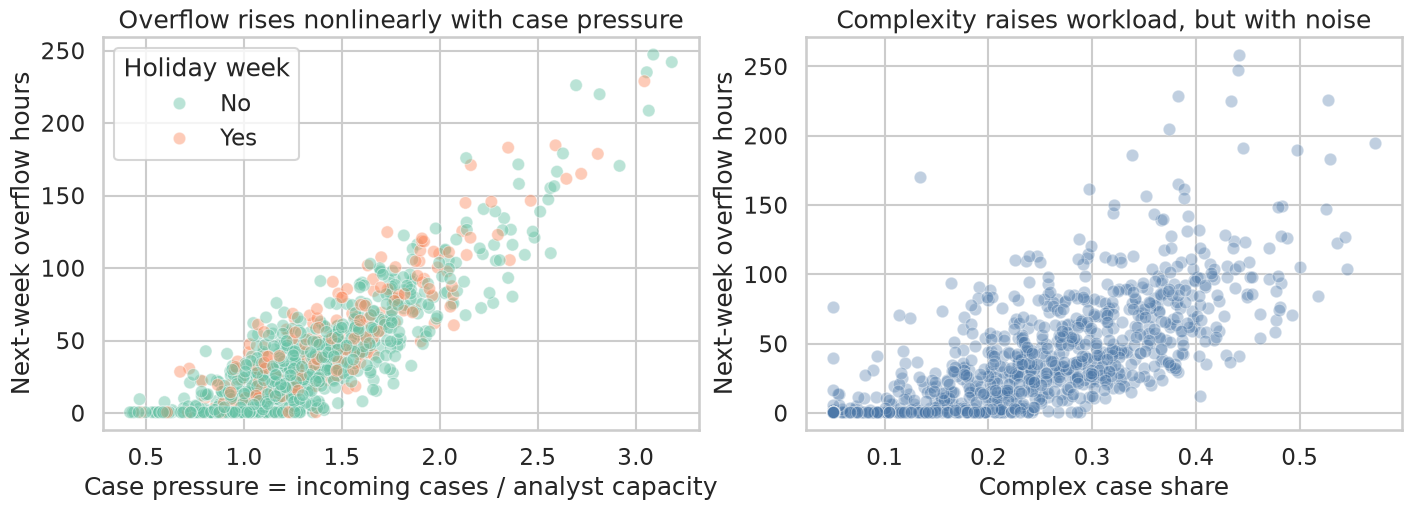

In [3]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

pressure_plot_df = staffing_df.sample(900, random_state=15).assign(
    holiday_week_label=lambda df: df['holiday_week'].map({0: 'No', 1: 'Yes'})
)

sns.scatterplot(
    data=pressure_plot_df,
    x='case_pressure',
    y=target_column,
    hue='holiday_week_label',
    hue_order=['No', 'Yes'],
    alpha=0.45,
    palette='Set2',
    ax=axes[0],
)
axes[0].set_title('Overflow rises nonlinearly with case pressure')
axes[0].set_xlabel('Case pressure = incoming cases / analyst capacity')
axes[0].set_ylabel('Next-week overflow hours')
axes[0].legend(title='Holiday week')

sns.scatterplot(
    data=staffing_df.sample(900, random_state=21),
    x='complex_case_share',
    y=target_column,
    alpha=0.35,
    color='#4C78A8',
    ax=axes[1],
)
axes[1].set_title('Complexity raises workload, but with noise')
axes[1].set_xlabel('Complex case share')
axes[1].set_ylabel('Next-week overflow hours')

plt.show()



The scatterplots already hint at the modeling challenge. Some relationships look roughly linear, but others bend or interact. That creates a natural temptation to use a richer basis expansion. The catch is that flexibility is never free. The same machinery that captures genuine curvature can also chase random fluctuation.



## 2. Tune Regularized Polynomial Models on the Validation Set

We will compare several models, but two of them need tuning:

- **ridge regression**, which keeps all predictors but shrinks coefficients toward zero;
- **lasso**, which both shrinks coefficients and can set some of them exactly to zero.

Both are fitted on a cubic polynomial basis so that nonlinear effects and interactions are available. The validation set chooses the penalty strength. This is intentionally simple and transparent. In larger workflows, one often replaces a single validation split with nested cross-validation, but the logic is the same: tuning must happen on data that are distinct from the final test set.


,alpha,validation_rmse,coefficient_l2_norm
0,0.003,11.690,802.731
1,0.009,11.324,565.271
2,0.025,10.928,369.300
3,0.071,10.555,229.153
4,0.200,10.204,140.929
5,0.562,9.904,86.424
6,1.585,9.669,53.348
7,4.467,9.484,33.877
8,12.589,9.365,22.542
9,35.481,9.336,15.836


,alpha,validation_rmse,nonzero_coefficients
0,0.003,9.668,288
1,0.009,9.339,210
2,0.025,9.200,153
3,0.071,9.236,88
4,0.200,9.245,43
5,0.562,9.307,22
6,1.585,9.706,12
7,4.467,11.521,8
8,12.589,15.668,2
9,35.481,32.883,2


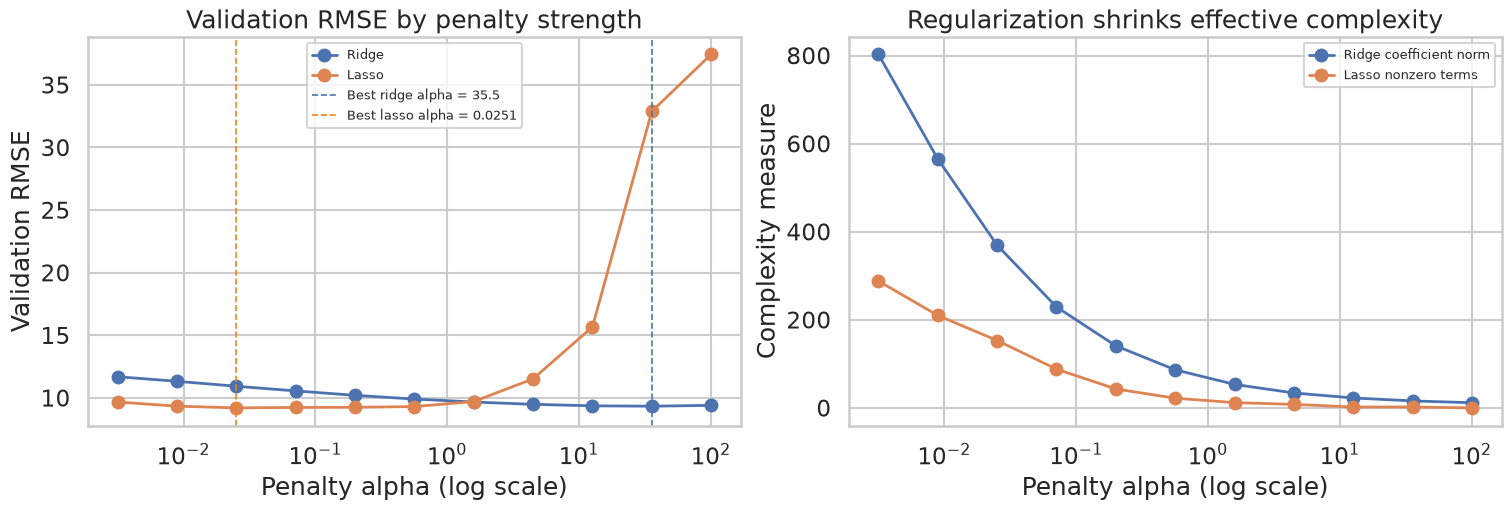

The validation split chooses **ridge alpha = 35.481** and **lasso alpha = 0.025**. As the penalty grows, the model pays for flexibility by shrinking or dropping terms. The aim of regularization is not aesthetic simplicity; it is better out-of-sample behavior.

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
X_train = train_df[feature_columns]
y_train = train_df[target_column]
X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]
X_test = test_df[feature_columns]
y_test = test_df[target_column]

alpha_grid = np.logspace(-2.5, 2, 11)
ridge_tuning_rows = []
lasso_tuning_rows = []

for alpha in alpha_grid:
    ridge_model = make_ridge_model(alpha)
    ridge_model.fit(X_train, y_train)
    ridge_pred = ridge_model.predict(X_validation)
    ridge_coef = ridge_model.named_steps['model'].coef_
    ridge_tuning_rows.append(
        {
            'alpha': alpha,
            'validation_rmse': rmse(y_validation, ridge_pred),
            'coefficient_l2_norm': np.linalg.norm(ridge_coef),
        }
    )

    lasso_model = make_lasso_model(alpha)
    lasso_model.fit(X_train, y_train)
    lasso_pred = lasso_model.predict(X_validation)
    lasso_coef = lasso_model.named_steps['model'].coef_
    lasso_tuning_rows.append(
        {
            'alpha': alpha,
            'validation_rmse': rmse(y_validation, lasso_pred),
            'nonzero_coefficients': int((np.abs(lasso_coef) > 1e-8).sum()),
        }
    )

ridge_tuning = pd.DataFrame(ridge_tuning_rows)
lasso_tuning = pd.DataFrame(lasso_tuning_rows)

best_ridge_alpha = ridge_tuning.loc[ridge_tuning['validation_rmse'].idxmin(), 'alpha']
best_lasso_alpha = lasso_tuning.loc[lasso_tuning['validation_rmse'].idxmin(), 'alpha']

smart_display(ridge_tuning)
smart_display(lasso_tuning)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axes[0].plot(ridge_tuning['alpha'], ridge_tuning['validation_rmse'], marker='o', linewidth=2, label='Ridge')
axes[0].plot(lasso_tuning['alpha'], lasso_tuning['validation_rmse'], marker='o', linewidth=2, label='Lasso')
axes[0].axvline(best_ridge_alpha, color='#4C78A8', linestyle='--', linewidth=1.2, label=f'Best ridge alpha = {best_ridge_alpha:.3g}')
axes[0].axvline(best_lasso_alpha, color='#F58518', linestyle='--', linewidth=1.2, label=f'Best lasso alpha = {best_lasso_alpha:.3g}')
axes[0].set_xscale('log')
axes[0].set_title('Validation RMSE by penalty strength')
axes[0].set_xlabel('Penalty alpha (log scale)')
axes[0].set_ylabel('Validation RMSE')
axes[0].legend(fontsize=9)

axes[1].plot(ridge_tuning['alpha'], ridge_tuning['coefficient_l2_norm'], marker='o', linewidth=2, label='Ridge coefficient norm')
axes[1].plot(lasso_tuning['alpha'], lasso_tuning['nonzero_coefficients'], marker='o', linewidth=2, label='Lasso nonzero terms')
axes[1].set_xscale('log')
axes[1].set_title('Regularization shrinks effective complexity')
axes[1].set_xlabel('Penalty alpha (log scale)')
axes[1].set_ylabel('Complexity measure')
axes[1].legend(fontsize=9)

plt.show()

display(
    Markdown(
        f"The validation split chooses **ridge alpha = {best_ridge_alpha:.3f}** and **lasso alpha = {best_lasso_alpha:.3f}**. "
        "As the penalty grows, the model pays for flexibility by shrinking or dropping terms. The aim of regularization is not aesthetic simplicity; it is better out-of-sample behavior."
    )
)



A useful way to phrase the trade-off is this: unregularized flexible models act as if every wiggle in the training data deserves explanation. Ridge and lasso insist on skepticism. They allow flexibility, but only after the signal is strong enough to survive a penalty.



## 3. First Comparison: Train Versus Validation Performance

We now compare six candidate models:

1. mean baseline;
2. linear main-effects regression;
3. cubic polynomial regression without regularization;
4. cubic ridge regression with validation-chosen penalty;
5. cubic lasso with validation-chosen penalty;
6. random forest regression.

The training error tells us how well each model fits the sample it saw. The validation error tells us how well that fit survives contact with new data. The gap between the two is often the most educational number on the page.


,model,train_rmse,validation_rmse,train_validation_gap,validation_mae,validation_r2
4,Cubic lasso,8.737,9.200,0.463,7.201,0.940
3,Cubic ridge,8.700,9.336,0.636,7.335,0.938
5,Random forest,8.855,10.531,1.676,7.937,0.921
1,Linear regression,11.497,10.958,-0.539,8.814,0.914
2,Cubic OLS,7.080,12.818,5.738,9.296,0.883
0,Mean baseline,43.232,37.435,-5.797,29.608,-0.001


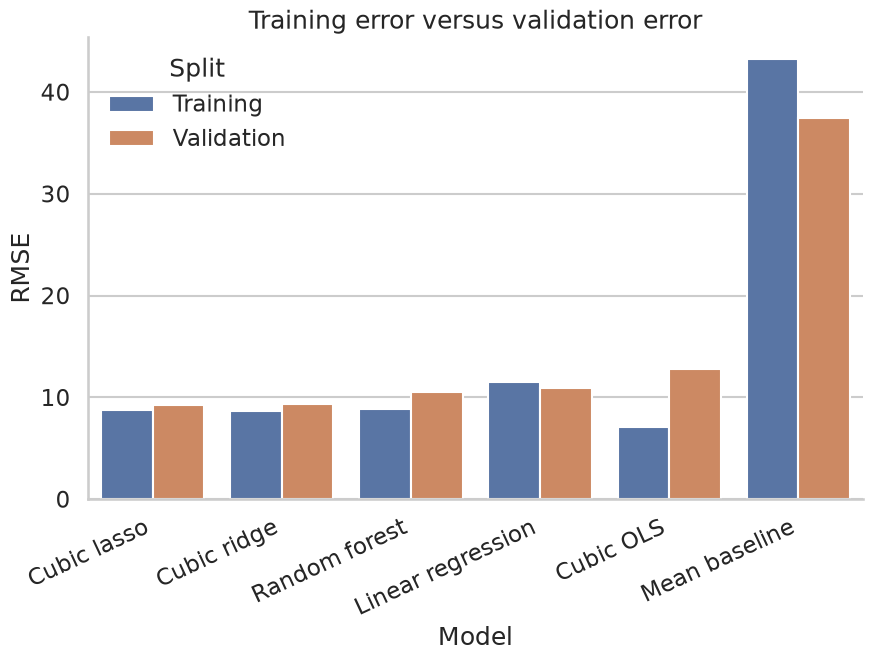

The best validation RMSE comes from **Cubic lasso** at **9.20 hours**. The largest train-validation gap belongs to **Cubic OLS**, which is the clearest sign of overfitting in this comparison. A model that dominates the training set but loses ground on validation data is not more intelligent; it is more fragile.

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
candidate_models = {
    'Mean baseline': make_mean_baseline(),
    'Linear regression': make_linear_model(),
    'Cubic OLS': make_poly_ols_model(),
    'Cubic ridge': make_ridge_model(best_ridge_alpha),
    'Cubic lasso': make_lasso_model(best_lasso_alpha),
    'Random forest': make_forest_model(),
}

comparison_rows = []
fitted_models = {}
for model_name, model in candidate_models.items():
    fitted, train_scores, valid_scores = evaluate_split(model, X_train, y_train, X_validation, y_validation)
    fitted_models[model_name] = fitted
    comparison_rows.append(
        {
            'model': model_name,
            'train_rmse': train_scores['rmse'],
            'validation_rmse': valid_scores['rmse'],
            'train_validation_gap': valid_scores['rmse'] - train_scores['rmse'],
            'validation_mae': valid_scores['mae'],
            'validation_r2': valid_scores['r2'],
        }
    )

comparison_table = pd.DataFrame(comparison_rows).sort_values('validation_rmse')
smart_display(comparison_table)

best_validation_model = comparison_table.iloc[0]['model']
largest_gap_model = comparison_table.sort_values('train_validation_gap', ascending=False).iloc[0]['model']

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = comparison_table.melt(
    id_vars='model',
    value_vars=['train_rmse', 'validation_rmse'],
    var_name='split',
    value_name='rmse',
)
plot_df['split'] = plot_df['split'].map({'train_rmse': 'Training', 'validation_rmse': 'Validation'})
sns.barplot(data=plot_df, x='model', y='rmse', hue='split', ax=ax)
ax.set_title('Training error versus validation error')
ax.set_xlabel('Model')
ax.set_ylabel('RMSE')
ax.tick_params(axis='x', rotation=25)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
ax.legend(title='Split', frameon=False)
sns.despine(fig=fig)
plt.show()

best_row = comparison_table.iloc[0]
display(
    Markdown(
        f"The best validation RMSE comes from **{best_validation_model}** at **{best_row['validation_rmse']:.2f} hours**. "
        f"The largest train-validation gap belongs to **{largest_gap_model}**, which is the clearest sign of overfitting in this comparison. "
        "A model that dominates the training set but loses ground on validation data is not more intelligent; it is more fragile."
    )
)



One subtle point is worth emphasizing. Validation performance is still a *sample estimate*. If we compare enough models, one will look best partly by luck. This is why later sections add repeated cross-validation and bootstrap optimism. Model selection should accumulate evidence, not depend on one lucky split.



## 4. Repeated Cross-Validation as a Stability Check

A single validation split is easy to explain, but it is also noisy. Different random splits would produce slightly different answers. Repeated cross-validation addresses that by averaging performance across many train-holdout partitions.

Here we use repeated $6$-fold cross-validation on the **development set** (training plus validation combined). This is not replacing the final test set; it is helping us judge how much performance dispersion each candidate model exhibits before we lock one in.


,model,mean_cv_rmse,sd_cv_rmse,min_cv_rmse,max_cv_rmse
3,Cubic lasso,9.538,0.438,8.813,10.505
2,Cubic ridge,9.624,0.423,8.885,10.514
4,Random forest,11.189,0.978,9.852,13.631
0,Linear regression,11.447,0.450,10.543,12.536
1,Cubic OLS,12.515,0.781,11.279,14.547


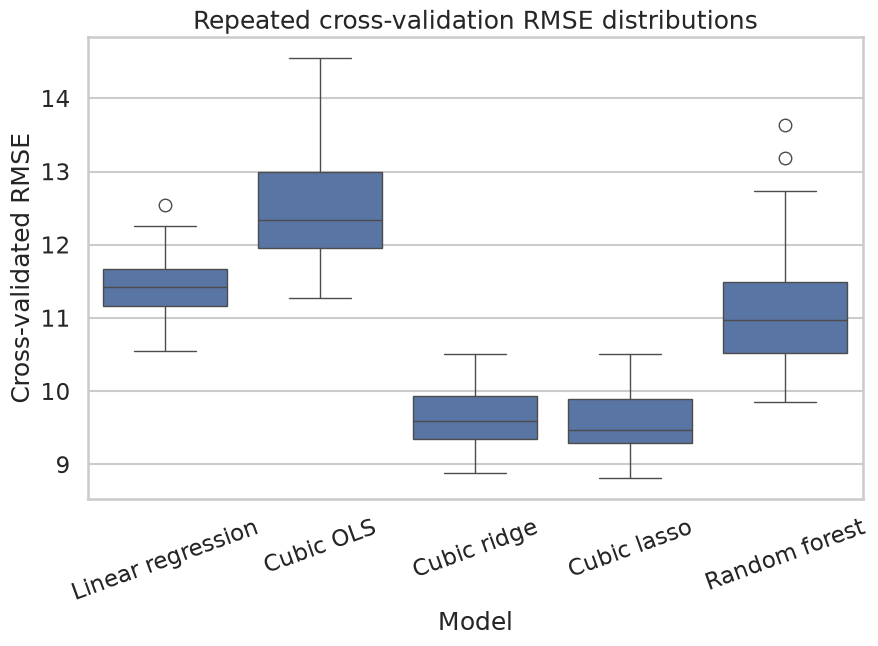

Across repeated cross-validation, **Cubic lasso** has the lowest mean RMSE. The narrowest performance dispersion belongs to **Cubic ridge**. That distinction matters: the numerically best average model is not always the most stable one, and high-stakes settings may value consistency nearly as much as raw accuracy.

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
development_X = development_df[feature_columns]
development_y = development_df[target_column]

cv_models = {
    'Linear regression': make_linear_model(),
    'Cubic OLS': make_poly_ols_model(),
    'Cubic ridge': make_ridge_model(best_ridge_alpha),
    'Cubic lasso': make_lasso_model(best_lasso_alpha),
    'Random forest': make_forest_model(),
}

rkf = RepeatedKFold(n_splits=6, n_repeats=4, random_state=15)
cv_rows = []
cv_distributions = []

for model_name, model in cv_models.items():
    scores = cross_validate(
        model,
        development_X,
        development_y,
        cv=rkf,
        scoring='neg_root_mean_squared_error',
        n_jobs=None,
        return_train_score=False,
    )
    rmse_scores = -scores['test_score']
    cv_rows.append(
        {
            'model': model_name,
            'mean_cv_rmse': rmse_scores.mean(),
            'sd_cv_rmse': rmse_scores.std(ddof=1),
            'min_cv_rmse': rmse_scores.min(),
            'max_cv_rmse': rmse_scores.max(),
        }
    )
    cv_distributions.extend(
        [{'model': model_name, 'cv_rmse': value} for value in rmse_scores]
    )

cv_summary = pd.DataFrame(cv_rows).sort_values('mean_cv_rmse')
cv_distribution_df = pd.DataFrame(cv_distributions)
smart_display(cv_summary)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=cv_distribution_df, x='model', y='cv_rmse', ax=ax)
ax.set_title('Repeated cross-validation RMSE distributions')
ax.set_xlabel('Model')
ax.set_ylabel('Cross-validated RMSE')
ax.tick_params(axis='x', rotation=20)
plt.show()

stable_model = cv_summary.sort_values(['mean_cv_rmse', 'sd_cv_rmse']).iloc[0]['model']
lowest_dispersion_model = cv_summary.sort_values('sd_cv_rmse').iloc[0]['model']

display(
    Markdown(
        f"Across repeated cross-validation, **{stable_model}** has the lowest mean RMSE. "
        f"The narrowest performance dispersion belongs to **{lowest_dispersion_model}**. "
        "That distinction matters: the numerically best average model is not always the most stable one, and high-stakes settings may value consistency nearly as much as raw accuracy."
    )
)


The repeated cross-validation experiment recombines the original training and validation data into a development set, then repeatedly creates fresh folds. This is a stability check, not a new final evaluation. It asks whether the model ranking survives different train-holdout partitions or whether one model looked best only because of a lucky split.

This matters for staffing decisions because one unusually friendly validation set can make a fragile model look deployable. Repeated cross-validation gives a distribution of errors, so we can compare both average performance and variability.


## 5. Bootstrap Optimism: How Much Does Training Error Understate Future Error?

Training error is usually optimistic because the model has already seen those outcomes. The more flexible the model, the more severe that optimism can become.

Bootstrap optimism offers a practical correction. We repeatedly resample the development data with replacement, fit a model on the bootstrap sample, and compare:

- the error on the bootstrap sample itself;
- the error that same fitted model incurs on the original development data.

Their difference estimates how much training performance is flattering the model. We compute this for three nested models: linear regression, cubic OLS, and cubic ridge.


,apparent_rmse,mean_optimism,optimism_corrected_rmse,optimism_sd,model
1,7.630,4.176,11.806,0.560,Cubic OLS
2,8.703,0.804,9.507,0.146,Cubic ridge
0,11.336,0.073,11.409,0.204,Linear regression


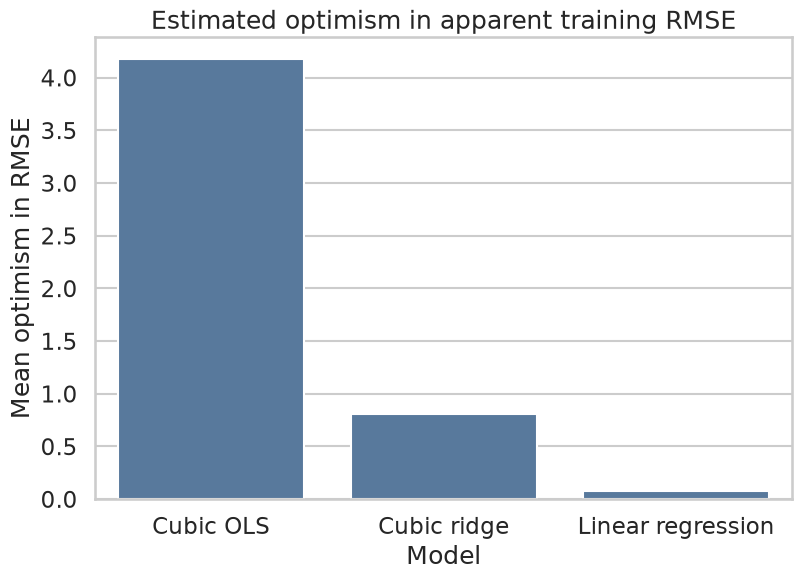

The largest optimism correction is attached to **Cubic OLS**, while **Linear regression** is least flattered by its training fit. This is exactly what we expect from the bias-variance story: flexible unpenalized models often look unusually strong on the data they were allowed to memorize.

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
optimism_models = {
    'Linear regression': make_linear_model(),
    'Cubic OLS': make_poly_ols_model(),
    'Cubic ridge': make_ridge_model(best_ridge_alpha),
}

optimism_rows = []
for model_name, model in optimism_models.items():
    optimism_result = bootstrap_optimism(model, development_X, development_y, n_boot=90, seed=15)
    optimism_result['model'] = model_name
    optimism_rows.append(optimism_result)

optimism_table = pd.DataFrame(optimism_rows).sort_values('mean_optimism', ascending=False)
smart_display(optimism_table)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=optimism_table, x='model', y='mean_optimism', ax=ax, color='#4C78A8')
ax.set_title('Estimated optimism in apparent training RMSE')
ax.set_xlabel('Model')
ax.set_ylabel('Mean optimism in RMSE')
plt.show()

most_optimistic_model = optimism_table.iloc[0]['model']
least_optimistic_model = optimism_table.iloc[-1]['model']

display(
    Markdown(
        f"The largest optimism correction is attached to **{most_optimistic_model}**, while **{least_optimistic_model}** is least flattered by its training fit. "
        "This is exactly what we expect from the bias-variance story: flexible unpenalized models often look unusually strong on the data they were allowed to memorize."
    )
)


The bootstrap optimism experiment studies how much a model is flattered by the data it was allowed to fit. For each bootstrap sample, the model is trained on resampled data and then compared against the original development data. The gap estimates how much apparent training performance understates future error.

This experiment is especially useful for contrasting flexible unpenalized models with regularized models. If a model can memorize accidental patterns, its training error can look impressive while its optimism correction grows large.


## 6. What Regularization Does to the Coefficient Landscape

Regularization is often described abstractly as adding a penalty to the loss function. That is mathematically true, but operationally incomplete. What analysts usually care about is what the penalty does to the model description.

- **Ridge** shrinks many coefficients together, especially when predictors are correlated.
- **Lasso** can collapse weak terms to exactly zero, creating a sparser description.

Because we fitted these models on a cubic basis, the total feature space is large. Looking at how many terms survive is a useful reality check.


In [8]:
# Fit the statistical or machine-learning model used for this comparison.
poly_feature_names = fitted_models['Cubic ridge'].named_steps['poly'].get_feature_names_out(feature_columns)

ridge_dev = make_ridge_model(best_ridge_alpha)
ridge_dev.fit(development_X, development_y)
lasso_dev = make_lasso_model(best_lasso_alpha)
lasso_dev.fit(development_X, development_y)
poly_ols_dev = make_poly_ols_model()
poly_ols_dev.fit(development_X, development_y)

ridge_coef = ridge_dev.named_steps['model'].coef_
lasso_coef = lasso_dev.named_steps['model'].coef_
poly_coef = poly_ols_dev.named_steps['model'].coef_

coef_summary = pd.DataFrame(
    {
        'model': ['Cubic OLS', 'Cubic ridge', 'Cubic lasso'],
        'total_basis_terms': [len(poly_feature_names)] * 3,
        'nonzero_terms': [
            int((np.abs(poly_coef) > 1e-10).sum()),
            int((np.abs(ridge_coef) > 1e-10).sum()),
            int((np.abs(lasso_coef) > 1e-10).sum()),
        ],
        'coefficient_l2_norm': [
            np.linalg.norm(poly_coef),
            np.linalg.norm(ridge_coef),
            np.linalg.norm(lasso_coef),
        ],
    }
)
smart_display(coef_summary)

lasso_top_terms = pd.DataFrame(
    {
        'term': poly_feature_names,
        'coefficient': lasso_coef,
        'abs_coefficient': np.abs(lasso_coef),
    }
)
lasso_top_terms = lasso_top_terms.query('abs_coefficient > 1e-10').sort_values('abs_coefficient', ascending=False).head(15)
smart_display(lasso_top_terms.drop(columns='abs_coefficient'))

retained_terms = int((np.abs(lasso_coef) > 1e-10).sum())
total_terms = len(poly_feature_names)

display(
    Markdown(
        f"The cubic polynomial basis contains **{total_terms} terms**. Lasso retains only **{retained_terms}** of them on the development data, while ridge keeps the full basis but shrinks it. "
        "This is why the two penalties often serve different goals: ridge for distributed shrinkage under collinearity, lasso for parsimony when many terms appear expendable."
    )
)


,model,total_basis_terms,nonzero_terms,coefficient_l2_norm
0,Cubic OLS,559,559,2900.751
1,Cubic ridge,559,559,16.571
2,Cubic lasso,559,138,23.391


,term,coefficient
539,case_pressure^3,13.675740
27,backlog_hours complex_case_share,7.033704
14,incoming_cases backlog_hours,5.838172
26,backlog_hours^2,4.797639
219,backlog_hours automation_rate analyst_capacity,-4.737356
185,incoming_cases case_pressure^2,4.459872
94,case_pressure^2,4.452447
32,backlog_hours enterprise_share,3.727230
208,backlog_hours complex_case_share automation_rate,3.712658
209,backlog_hours complex_case_share analyst_capacity,3.708921


The cubic polynomial basis contains **559 terms**. Lasso retains only **138** of them on the development data, while ridge keeps the full basis but shrinks it. This is why the two penalties often serve different goals: ridge for distributed shrinkage under collinearity, lasso for parsimony when many terms appear expendable.

The coefficient-landscape section explains what regularization is doing inside the model. Cubic polynomial features create hundreds of basis terms, including nonlinear transformations and interactions. That expansion is powerful, but it also creates many opportunities to chase noise.

The comparison among cubic OLS, ridge, and lasso shows three different responses to that flexibility. OLS keeps every term freely estimated. Ridge keeps every term but shrinks the coefficient vector. Lasso can shrink weak terms exactly to zero. This comparison is about prediction, interpretability, and stability.


## 7. Final Test-Set Evaluation

After tuning on the validation set and checking stability on the development set, we can finally touch the test set. This is the moment of truth. The test set is not for additional tuning; it is for measuring how well the full selection process generalized.

To be fair, each candidate model is now refit on the full development set before its single test-set evaluation.


,model,test_rmse,test_mae,test_r2
4,Cubic lasso,9.716,7.599,0.940
3,Cubic ridge,9.869,7.702,0.938
5,Random forest,11.113,8.525,0.921
1,Linear regression,11.881,9.172,0.910
2,Cubic OLS,12.388,9.070,0.902
0,Mean baseline,39.587,29.176,-0.001


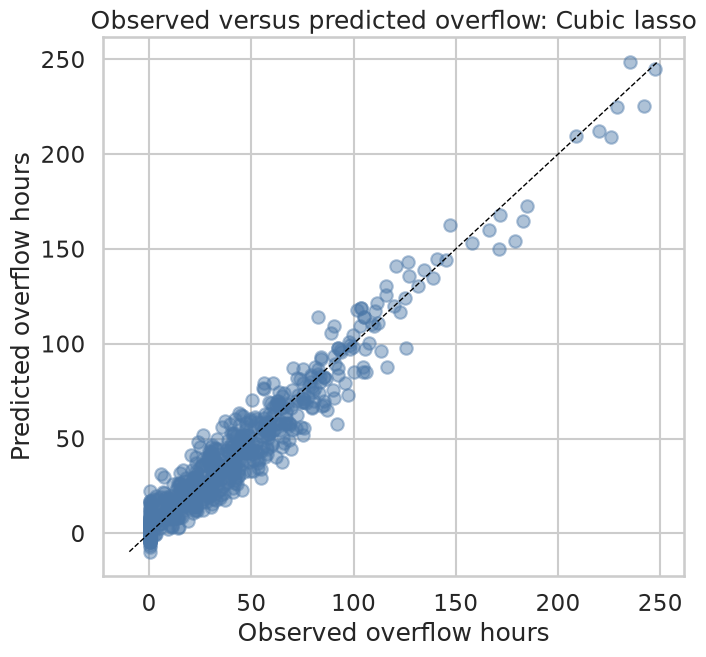

On the final test set, **Cubic lasso** performs best with an RMSE of **9.72 hours**, followed by **Cubic ridge**. Its earlier validation RMSE was **9.20**, and its repeated-CV mean RMSE was **9.54**, which gives us a useful triangulation: the model selection story is not resting on one lucky number alone.

In [9]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
final_rows = []
final_fitted = {}
for model_name, model in candidate_models.items():
    fitted = clone(model)
    fitted.fit(development_X, development_y)
    final_fitted[model_name] = fitted
    pred = fitted.predict(X_test)
    scores = regression_scores(y_test, pred)
    final_rows.append(
        {
            'model': model_name,
            'test_rmse': scores['rmse'],
            'test_mae': scores['mae'],
            'test_r2': scores['r2'],
        }
    )

final_table = pd.DataFrame(final_rows).sort_values('test_rmse')
smart_display(final_table)

winner_name = final_table.iloc[0]['model']
runner_up_name = final_table.iloc[1]['model']
winning_model = final_fitted[winner_name]
winning_predictions = winning_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(y_test, winning_predictions, alpha=0.45, color='#4C78A8')
lims = [min(y_test.min(), winning_predictions.min()), max(y_test.max(), winning_predictions.max())]
ax.plot(lims, lims, linestyle='--', color='black', linewidth=1)
ax.set_title(f'Observed versus predicted overflow: {winner_name}')
ax.set_xlabel('Observed overflow hours')
ax.set_ylabel('Predicted overflow hours')
plt.show()

winner_cv = cv_summary.set_index('model').loc[winner_name, 'mean_cv_rmse'] if winner_name in cv_summary['model'].values else np.nan
winner_validation = comparison_table.set_index('model').loc[winner_name, 'validation_rmse'] if winner_name in comparison_table['model'].values else np.nan


display(
    Markdown(
        f"On the final test set, **{winner_name}** performs best with an RMSE of **{final_table.iloc[0]['test_rmse']:.2f} hours**, followed by **{runner_up_name}**. "
        f"Its earlier validation RMSE was **{winner_validation:.2f}**, and its repeated-CV mean RMSE was **{winner_cv:.2f}**, which gives us a useful triangulation: the model selection story is not resting on one lucky number alone."
    )
)



## 8. How to Read These Results

We use ridge, lasso, and forests to teach honest model evaluation.

Several habits matter:

1. **Preserve a final test set.** If every dataset is used for tuning, nothing remains to audit generalization.
2. **Look at train-validation gaps.** Apparent fit without honest holdout performance is mostly self-congratulation.
3. **Use repeated resampling.** A single split can be unlucky; repeated cross-validation reveals how noisy the ranking is.
4. **Treat regularization as discipline.** Shrinkage prevents the model from explaining every accidental wrinkle.
5. **Prefer models that match the decision environment.** In some settings the best model is the one with the smallest error. In others it is the one with nearly the same error, tighter dispersion, and a clearer explanation surface.

A strong statistical recommendation could say the following. *Based on holdout performance, repeated cross-validation, and optimism checks, model X appears to generalize best for this forecasting task. Expected deployment error remains nontrivial, so staffing decisions should still include buffer capacity and periodic recalibration.* That is the tone of real decision support, useful, quantitative, and cautious without becoming timid.


## 9. Real-Data Companion: Random Splits Versus Time Splits in Bike Sharing

The synthetic validation workflow above lets us control the truth. Real forecasting adds another problem: the future is not a random sample of the past. The UCI Bike Sharing data are hourly observations with calendar order, seasonality, weather, working-day patterns, and changing demand levels. Those features make the validation design part of the statistical argument.

The target is hourly rental count. Predictors include weather and calendar variables that are partly predictable before deployment, but the evaluation question is still temporal: can a model trained on earlier observations perform on later observations? A random split can mix hours from the same season or nearby periods into both training and test sets, which may make performance look more stable than a real forward-looking forecast.

The companion compares the same modeling workflow under a random split and a time-ordered split. Validation must match deployment. If the decision is about future weeks or months, the test design should preserve time order.

For clarity, the unit is an hourly rental observation ordered in time. The outcome is rental count, and the experiment compares random validation with forward-looking validation. The dataset matters because time order changes what honest generalization means.

Data source: [UCI Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset).

,validation_design,rmse,mae,deployment_match
0,Random split,47.800000,29.230000,Weak for future forecasting
1,Time-ordered split,78.720000,51.360000,Closer to forecasting the next period


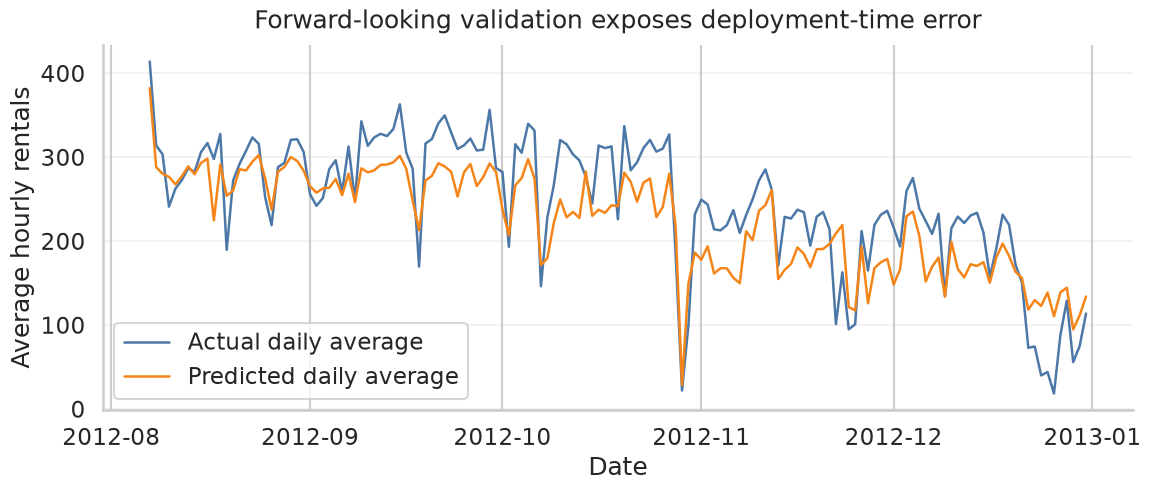

In [10]:
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_uci_bike_sharing, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from sklearn.model_selection import train_test_split

    bike = load_uci_bike_sharing().sort_values(["dteday", "hr"]).reset_index(drop=True)
    features = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]
    X = bike[features]
    y = bike["cnt"]

    model = RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=10,
        random_state=2026,
        n_jobs=-1,
    )

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X, y, test_size=0.20, random_state=2026
    )
    model.fit(X_train_r, y_train_r)
    random_pred = model.predict(X_test_r)

    split = int(len(bike) * 0.80)
    X_train_t, X_test_t = X.iloc[:split], X.iloc[split:]
    y_train_t, y_test_t = y.iloc[:split], y.iloc[split:]
    model.fit(X_train_t, y_train_t)
    time_pred = model.predict(X_test_t)

    split_table = pd.DataFrame(
        [
            {
                "validation_design": "Random split",
                "rmse": np.sqrt(mean_squared_error(y_test_r, random_pred)),
                "mae": mean_absolute_error(y_test_r, random_pred),
                "deployment_match": "Weak for future forecasting",
            },
            {
                "validation_design": "Time-ordered split",
                "rmse": np.sqrt(mean_squared_error(y_test_t, time_pred)),
                "mae": mean_absolute_error(y_test_t, time_pred),
                "deployment_match": "Closer to forecasting the next period",
            },
        ]
    )
    smart_display(split_table.round(2))

    plot_df = pd.DataFrame(
        {
            "actual": y_test_t.to_numpy(),
            "predicted": time_pred,
            "date": bike.loc[y_test_t.index, "dteday"].to_numpy(),
        }
    ).groupby("date", as_index=False).mean(numeric_only=True)

    fig, ax = plt.subplots(figsize=(11.4, 4.8), constrained_layout=True)
    ax.plot(plot_df["date"], plot_df["actual"], label="Actual daily average", color="#4C78A8", linewidth=1.8)
    ax.plot(plot_df["date"], plot_df["predicted"], label="Predicted daily average", color="#F58518", linewidth=1.8)
    ax.set_title("Forward-looking validation exposes deployment-time error", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Average hourly rentals")
    ax.legend(loc="lower left", frameon=True)
    ax.grid(axis="y", alpha=0.25)
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "UCI Bike Sharing Dataset",
        "https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset",
        "RUN_REAL_DATA_COMPANION",
    )

If the time split performs worse than the random split, that is not a failure of the notebook. It is the lesson. Validation is part of the decision design. A split that ignores time can make a forecasting workflow look more stable than it will be in production.


## References

- Efron, B. (1983). *Estimating the error rate of a prediction rule: Improvement on cross-validation*. *Journal of the American Statistical Association, 78*(382), 316-331. [https://doi.org/10.1080/01621459.1983.10477973](https://doi.org/10.1080/01621459.1983.10477973)
- Hoerl, A. E., & Kennard, R. W. (1970). *Ridge regression: Biased estimation for nonorthogonal problems*. *Technometrics, 12*(1), 55-67. [https://doi.org/10.1080/00401706.1970.10488634](https://doi.org/10.1080/00401706.1970.10488634)
- Tibshirani, R. (1996). *Regression shrinkage and selection via the lasso*. *Journal of the Royal Statistical Society: Series B (Methodological), 58*(1), 267-288. [https://doi.org/10.1111/j.2517-6161.1996.tb02080.x](https://doi.org/10.1111/j.2517-6161.1996.tb02080.x)
- van Houwelingen, H. C., & le Cessie, S. (1990). *Predictive value of statistical models*. *Statistics in Medicine, 9*(11), 1303-1325. [https://doi.org/10.1002/sim.4780091109](https://doi.org/10.1002/sim.4780091109)
